In [1]:
#Find Minimum and Maximum
def find_min_max(numbers):
    #print(numbers)
    n = numbers
    a = numbers[0]
    b = numbers[0]
    for i in n:
        high = a
        low = b
        if i > a:
            a = i
            high = a
        if i < b:
            b = i
            low = b     
    return high,low

numbers = (10,20,30)
#numbers = (-5, -8, -1, -10, -3)
find_min_max(numbers)

(30, 10)

In [2]:
#Min-Max Normalization
def min_max_normalize(value, data):
    max,min = find_min_max(data)
    l = len(data)
    if value == min:
        return 0
    elif value == max:
        return 1
    else:
        ans = (value-min)/((max-min))
    return ans


min_max_normalize(20, [10,20,30,40,60])    


0.2

In [3]:
#Compute Mean(mu)
def compute_mean(numbers):
    l = len(numbers)
    sum = 0
    if l == 0:
        return 0
    for i in numbers:
        sum = sum+i
    mean = sum/l
    return mean

n = (10, 20, 30)
compute_mean(n)

20.0

In [4]:
# Standard Deviation(sigma)
#SD jitna kam, data utna jada stable
from math import sqrt
def compute_sd(numbers):
    mu = compute_mean(numbers)
    sd = 0
    sd1 = 0
    n = len(numbers)
    for i in numbers:
        sd1 = sd1+(abs((i-mu)**2))/n
        #sd = sd+compute_mean(abs(sd1))
    sd = sqrt(sd1)
    return sd
#compute_sd([0, 100, 0, 100, 50])
compute_sd([10, 12, 12, 13, 12, 11, 90])

27.42485093814717

In [5]:
# Detect Outliers with Z-Score
#def find_outliers(nums, threshold):
def find_outliers(nums, threshold):
    mu = compute_mean(nums)
    sigma = compute_sd(nums)
    out = []
    for i in nums:
        x = i
        z = abs((x-mu)/sigma)
        if z > threshold:
            out.append(x)
            

    return out

find_outliers([48, 49, 50, 51, 52, 49, 50, 51, 48, 52, 90, 95], 2)
    


[90, 95]

In [6]:
#Interquartile Range (IQR)
def compute_iqr(data):
    l = len(data)
    p = l%2
    #print(p)
    half = round(l/2)
    half1 = round(half/2)
    data2 = []
    q1 = 0
    q2 = 0
    if p == 1:
        half = half+1
        half1 = half+1
    #print(half,half1)
    count = 0
    for i in data:
        count = count+1
        #print(half1)
        if count == half:
            q1 = i
            #return i
    #print(half)
    for j in range(half+1,len(data)+1):
        data2.append(j)
    print(data2)
    l2 = len(data2)
    p2 = l2%2
    count2 = 0
    #print(p)
    half2 = round(l2/2)
    half3 = round(half2/2)
    if p2 == 1:
        half2 = half2+1
        half3 = half3+1
    print(half2,half3)
    for k in data2:
        count2 = count2+1
        #print(half2)
        if count2 == half2:
            q2 = k
            #return i
    print(q1,q2)

compute_iqr([10, 20, 30, 40, 50, 60])


[4, 5, 6]
3 2
30 6


In [7]:
def median(values):
    n = len(values)
    mid = n // 2
    if n % 2 == 0:
        return (values[mid-1] + values[mid]) / 2
    else:
        return values[mid]

def compute_iqr(data):
    l = len(data)
    m = l%2
    f_half =[]
    s_half = []
    #print(n)
    if m==0:
        n = l//2
        f_half = data[:n]
        s_half = data[n:]
       
    if m == 1:
        n = (l+1)//2
        f_half = data[:n]
        n1 = n-1
        s_half = data[n1:]
        
    q1 = median(f_half)
    q3 = median(s_half)
    print(q1,q3)



        


compute_iqr([1, 2, 3, 4, 5, 6,7,8,9])

3 7


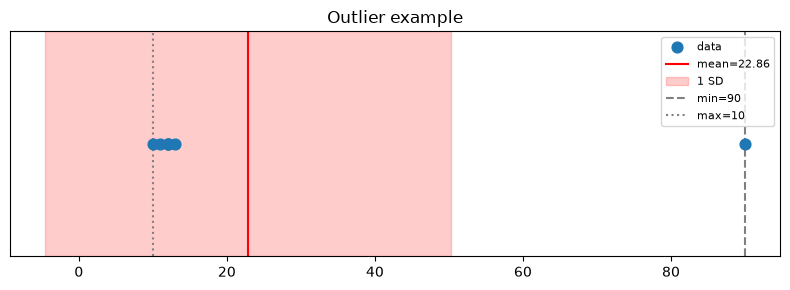

In [9]:

import matplotlib.pyplot as plt
def plot_stats(data, title="Dataset"):
    mu = compute_mean(data)
    sigma = compute_sd(data)
    mn, mx = find_min_max(data)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.scatter(data, [0] * len(data), s=60, zorder=3, label="data")
    ax.axvline(mu, color="red", label=f"mean={mu:.2f}")
    ax.axvspan(mu - sigma, mu + sigma, alpha=0.2,
               color="red", label=f"1 SD")
    ax.axvline(mn, color="gray", linestyle="--", label=f"min={mn}")
    ax.axvline(mx, color="gray", linestyle=":", label=f"max={mx}")
    ax.set_yticks([])
    ax.legend(fontsize=8)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_stats([10, 12, 12, 13, 12, 11, 90], "Outlier example")
